In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score

In [28]:
import os

print("Current folder:")
print(os.getcwd())

print("\nParent folder contents:")
print(os.listdir(".."))

Current folder:
c:\Users\HP\Downloads\PlantVillage_Project\visualization

Parent folder contents:
['.git', '.gitignore', 'dataset', 'dataset_link.txt', 'data_preparation', 'figures', 'modelling', 'models', 'processed_dataset', 'README.md', 'requirements.txt', 'results', 'visualization']


In [29]:
import os

for root, dirs, files in os.walk(".."):
    if "train" in dirs:
        print(os.path.join(root, "train"))

..\dataset\PlantVillage\train
..\dataset\PlantVillage_5Class\train
..\processed_dataset\train
..\processed_dataset\test\train
..\processed_dataset\train\train
..\processed_dataset\val\train


In [32]:
import tensorflow as tf

DATASET_PATH = "../dataset/PlantVillage_5Class/train"

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=(224,224),
    batch_size=32,
    shuffle=True
)

class_names = train_ds.class_names

print(class_names)

Found 4268 files belonging to 5 classes.
['Apple___Apple_scab', 'Apple___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Tomato___Late_blight']


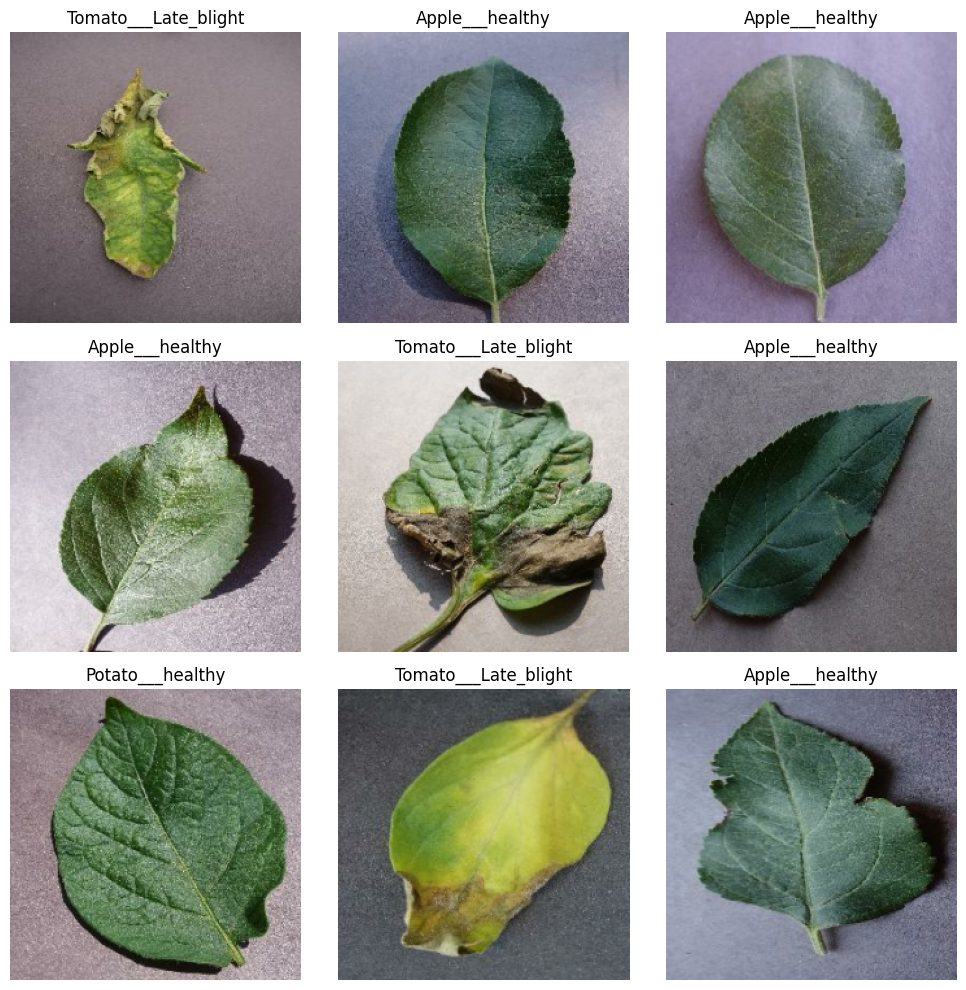

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.savefig("../results/dataset_samples.png")
plt.show()

In [16]:
VAL_DIR = "../dataset/PlantVillage_5Class/val"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = val_ds.class_names

print(class_names)

Found 1068 files belonging to 5 classes.
['Apple___Apple_scab', 'Apple___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Tomato___Late_blight']


In [17]:
VAL_DIR = "../dataset/PlantVillage_5Class/val"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = val_ds.class_names

Found 1068 files belonging to 5 classes.


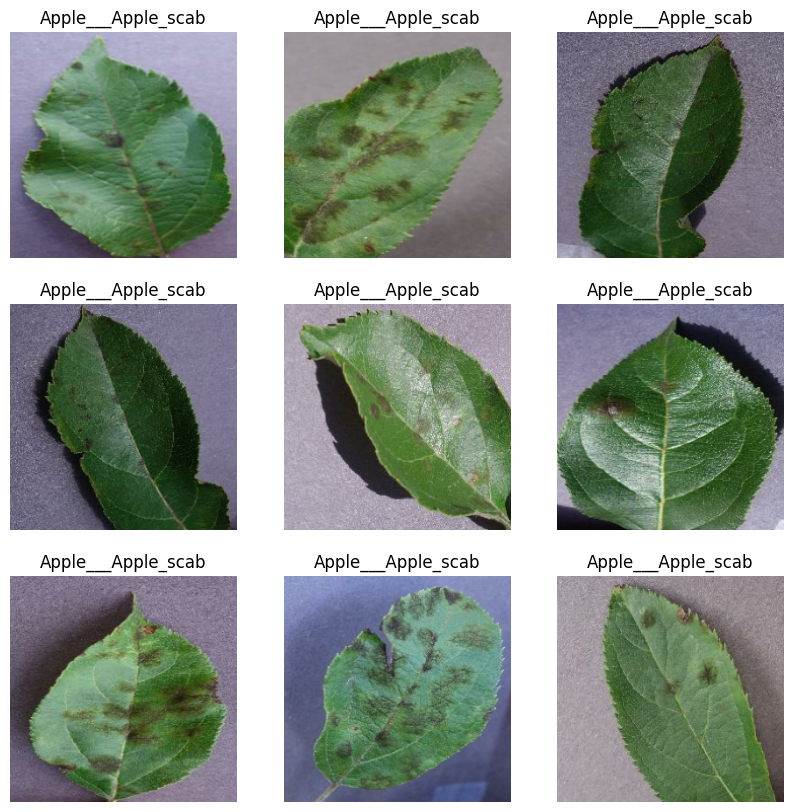

In [18]:
plt.figure(figsize=(10,10))

for images, labels in val_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [19]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["ResNet50", "DenseNet121", "MobileNetV3"],
    "Accuracy": [99.53, 97.85, 99.81],
    "Training Time (sec)": [1133, 2670, 398]
})

print(results)

         Model  Accuracy  Training Time (sec)
0     ResNet50     99.53                 1133
1  DenseNet121     97.85                 2670
2  MobileNetV3     99.81                  398


# Conclusion

Three CNN models were evaluated for plant disease classification.

- ResNet50 achieved high accuracy but required longer training time.
- DenseNet121 required the longest training time.
- MobileNetV3 achieved the highest accuracy and fastest training speed.

Therefore, MobileNetV3 is the most suitable model for this classification task.

In [20]:
model = tf.keras.models.load_model(
    "../models/mobilenetv3.keras"
)

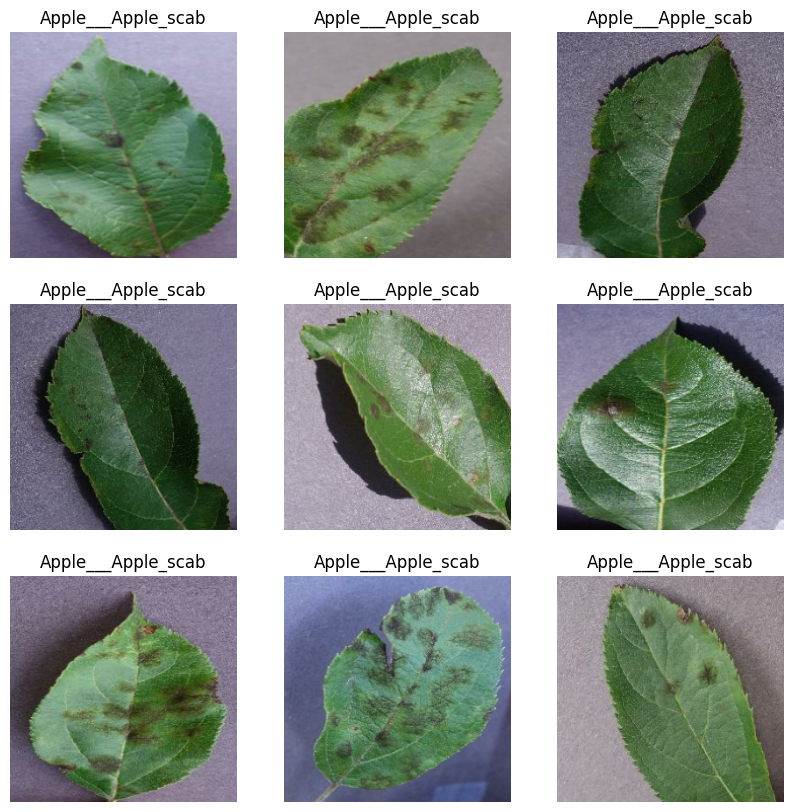

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in val_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [22]:
import pandas as pd

resnet = pd.read_csv("../results/resnet50_history.csv")
densenet = pd.read_csv("../results/densenet121_history.csv")
mobilenet = pd.read_csv("../results/mobilenetv3_history.csv")

In [34]:
print(os.listdir("../results"))

['dataset_samples.png', 'densenet121_history.csv', 'densenet_accuracy.png', 'densenet_loss.png', 'mobilenetv3_history.csv', 'mobilenet_accuracy.png', 'mobilenet_loss.png', 'model_accuracy.png', 'model_loss.png', 'resnet50_history.csv', 'resnet_accuracy.png', 'resnet_loss.png']


In [35]:
import tensorflow as tf
import numpy as np

VAL_PATH = "../dataset/PlantVillage_5Class/val"

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

class_names = val_ds.class_names

Found 1068 files belonging to 5 classes.
